# Lab | Deep Reinforcement Learning

This notebook completes the lab tasks:

- Random-action baseline on `CartPole-v1`
- DQN from scratch on `CartPole-v1`
- PPO with Stable-Baselines3 on `CartPole-v1`
- PPO with Stable-Baselines3 on `LunarLander-v2`
- Reward plots, comparison table, and reflection

## 0. Imports and setup

The install commands are intentionally not included because the environment setup is assumed to be done already.

In [1]:
import collections
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

device = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Device:", device)
print("Torch version:", torch.__version__)
print("Gymnasium version:", gym.__version__)

Device: cuda
Torch version: 2.12.0+cu132
Gymnasium version: 1.2.3


In [2]:
def make_env(env_id, seed=None, monitor=False):
    '''
    Small helper to create Gymnasium environments.
    For LunarLander, some Gymnasium versions use LunarLander-v3 instead of v2,
    so this function falls back automatically if needed.
    '''
    from stable_baselines3.common.monitor import Monitor

    try:
        env = gym.make(env_id)
    except Exception as first_error:
        if env_id == "LunarLander-v2":
            print("LunarLander-v2 failed, trying LunarLander-v3 instead...")
            env = gym.make("LunarLander-v3")
        else:
            raise first_error

    if seed is not None:
        env.reset(seed=seed)
        try:
            env.action_space.seed(seed)
        except Exception:
            pass

    if monitor:
        env = Monitor(env)

    return env


def moving_average(values, window=100):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return np.array([])
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(values, kernel, mode="valid")


def plot_rewards(rewards, title, window=100):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, alpha=0.35, label="Episode reward")

    ma = moving_average(rewards, window)
    if len(ma) > 0:
        plt.plot(np.arange(window - 1, window - 1 + len(ma)), ma, label=f"{window}-episode moving average")

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## 1. Random-action baseline on CartPole-v1

Before training any agent, we run one episode with random actions. This gives us a simple baseline that a learning agent should beat.

In [3]:
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=SEED)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Initial observation:", obs)

total_reward = 0
done = False

while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    done = terminated or truncated

env.close()

print("Random-action episode reward:", total_reward)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Random-action episode reward: 22.0


## 2. Task 1 — DQN from scratch on CartPole-v1

The DQN agent has:

- a Q-network
- a replay buffer
- a target network
- epsilon-greedy exploration
- one gradient update per environment step after the buffer warm-up

In [4]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32, device=device)
        actions = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=device)
        dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

In [5]:
def select_epsilon_greedy_action(q_net, state, epsilon, n_actions):
    if random.random() < epsilon:
        return random.randrange(n_actions)

    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = q_net(state_tensor)
    return int(torch.argmax(q_values, dim=1).item())


def train_dqn_cartpole(
    total_steps=30_000,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    replay_capacity=50_000,
    learning_starts=1_000,
    target_sync_every=1_000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=5_000,
    seed=SEED,
):
    env = gym.make("CartPole-v1")
    obs, info = env.reset(seed=seed)
    env.action_space.seed(seed)

    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    q_net = QNetwork(obs_dim, n_actions).to(device)
    target_net = QNetwork(obs_dim, n_actions).to(device)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(capacity=replay_capacity)

    episode_rewards = []
    current_episode_reward = 0.0
    losses = []

    t0 = time.perf_counter()

    for step in range(1, total_steps + 1):
        epsilon_fraction = min(1.0, step / epsilon_decay_steps)
        epsilon = epsilon_start + epsilon_fraction * (epsilon_end - epsilon_start)

        action = select_epsilon_greedy_action(q_net, obs, epsilon, n_actions)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(obs, action, reward, next_obs, done)

        obs = next_obs
        current_episode_reward += reward

        if done:
            episode_rewards.append(current_episode_reward)
            obs, info = env.reset()
            current_episode_reward = 0.0

        if len(replay_buffer) >= learning_starts:
            states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

            current_q_values = q_net(states).gather(1, actions)

            with torch.no_grad():
                next_q_values = target_net(next_states).max(dim=1, keepdim=True).values
                target_q_values = rewards + gamma * next_q_values * (1 - dones)

            loss = nn.functional.mse_loss(current_q_values, target_q_values)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        if step % target_sync_every == 0:
            target_net.load_state_dict(q_net.state_dict())

        if step % 5_000 == 0:
            if len(episode_rewards) >= 10:
                recent_avg = np.mean(episode_rewards[-10:])
                print(f"Step {step:>6} | episodes: {len(episode_rewards):>4} | recent avg reward: {recent_avg:>7.2f} | epsilon: {epsilon:.3f}")
            else:
                print(f"Step {step:>6} | episodes: {len(episode_rewards):>4} | epsilon: {epsilon:.3f}")

    train_time = time.perf_counter() - t0
    env.close()

    return q_net, episode_rewards, losses, train_time

In [6]:
dqn_model, dqn_rewards, dqn_losses, dqn_train_time = train_dqn_cartpole(total_steps=30_000)

dqn_last_100_avg = float(np.mean(dqn_rewards[-100:])) if len(dqn_rewards) >= 100 else float(np.mean(dqn_rewards))

print(f"DQN training time: {dqn_train_time:.1f} seconds")
print(f"DQN episodes completed: {len(dqn_rewards)}")
print(f"DQN average reward over last 100 episodes: {dqn_last_100_avg:.1f}")

Step   5000 | episodes:  213 | recent avg reward:   60.30 | epsilon: 0.050
Step  10000 | episodes:  245 | recent avg reward:  144.90 | epsilon: 0.050
Step  15000 | episodes:  282 | recent avg reward:  139.30 | epsilon: 0.050
Step  20000 | episodes:  318 | recent avg reward:  117.60 | epsilon: 0.050
Step  25000 | episodes:  359 | recent avg reward:  112.00 | epsilon: 0.050
Step  30000 | episodes:  404 | recent avg reward:  123.90 | epsilon: 0.050
DQN training time: 68.9 seconds
DQN episodes completed: 404
DQN average reward over last 100 episodes: 116.3


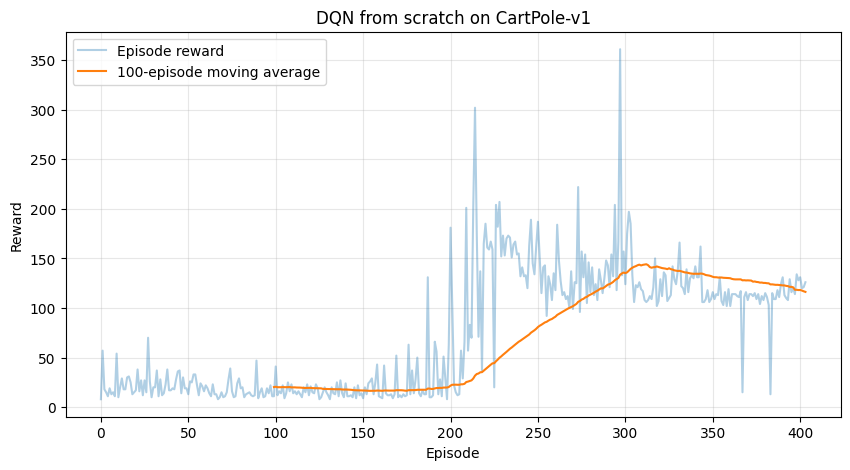

In [7]:
plot_rewards(dqn_rewards, "DQN from scratch on CartPole-v1", window=100)

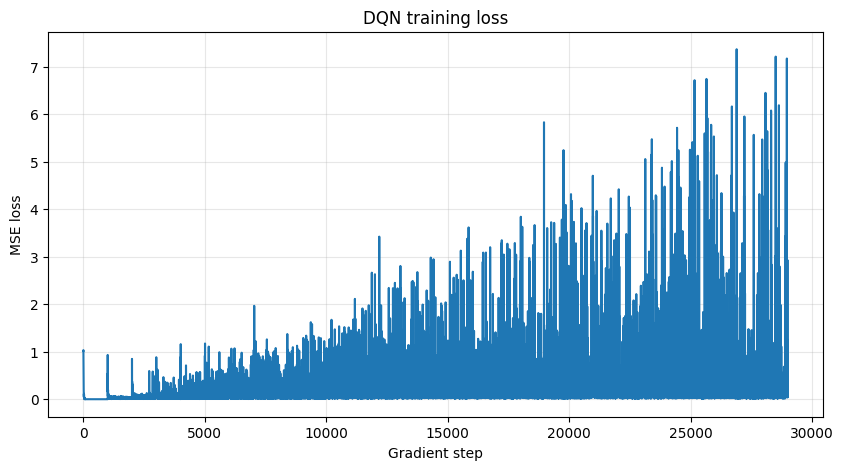

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(dqn_losses)
plt.title("DQN training loss")
plt.xlabel("Gradient step")
plt.ylabel("MSE loss")
plt.grid(alpha=0.3)
plt.show()

## 3. Task 2 — PPO with Stable-Baselines3

Now we train PPO using Stable-Baselines3.

The `Monitor` wrapper stores episode rewards, which we use for the reward curves.

In [9]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

### 3.1 PPO on CartPole-v1

In [10]:
ppo_cartpole_env = make_env("CartPole-v1", seed=SEED, monitor=True)

ppo_cartpole = PPO("MlpPolicy", ppo_cartpole_env, verbose=0, seed=SEED)

t0 = time.perf_counter()
ppo_cartpole.learn(total_timesteps=50_000)
cartpole_train_time = time.perf_counter() - t0

ppo_cartpole_rewards = ppo_cartpole_env.get_episode_rewards()
ppo_cartpole_last_100_avg = float(np.mean(ppo_cartpole_rewards[-100:])) if len(ppo_cartpole_rewards) >= 100 else float(np.mean(ppo_cartpole_rewards))

eval_env = make_env("CartPole-v1", seed=SEED + 1, monitor=True)
ppo_cartpole_mean_reward, ppo_cartpole_std_reward = evaluate_policy(
    ppo_cartpole,
    eval_env,
    n_eval_episodes=20,
    deterministic=True,
)
eval_env.close()
ppo_cartpole_env.close()

print(f"PPO CartPole: {ppo_cartpole_mean_reward:.1f} ± {ppo_cartpole_std_reward:.1f} over 20 episodes")
print(f"Training time: {cartpole_train_time:.1f} seconds")
print(f"Training episodes completed: {len(ppo_cartpole_rewards)}")
print(f"Average reward over last 100 training episodes: {ppo_cartpole_last_100_avg:.1f}")

c:\Users\Baku\anaconda3\envs\torch_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


PPO CartPole: 500.0 ± 0.0 over 20 episodes
Training time: 132.3 seconds
Training episodes completed: 363
Average reward over last 100 training episodes: 407.8


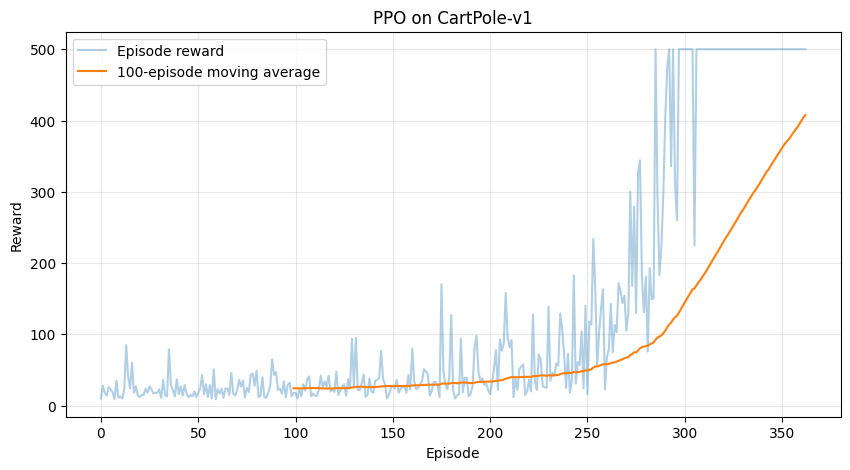

In [11]:
plot_rewards(ppo_cartpole_rewards, "PPO on CartPole-v1", window=100)

### 3.2 PPO on LunarLander-v2

This is the slowest cell in the notebook. The assignment asks for 300,000 timesteps.

In [12]:
ppo_ll_env = make_env("LunarLander-v2", seed=SEED, monitor=True)

ppo_ll = PPO("MlpPolicy", ppo_ll_env, verbose=0, seed=SEED)

t0 = time.perf_counter()
ppo_ll.learn(total_timesteps=300_000)
ll_train_time = time.perf_counter() - t0

ppo_ll_rewards = ppo_ll_env.get_episode_rewards()
ppo_ll_last_100_avg = float(np.mean(ppo_ll_rewards[-100:])) if len(ppo_ll_rewards) >= 100 else float(np.mean(ppo_ll_rewards))

# Evaluate using the same environment version if LunarLander-v2 had to fall back to LunarLander-v3.
ll_env_id_for_eval = ppo_ll_env.unwrapped.spec.id
eval_env_ll = make_env(ll_env_id_for_eval, seed=SEED + 1, monitor=True)

ppo_ll_mean_reward, ppo_ll_std_reward = evaluate_policy(
    ppo_ll,
    eval_env_ll,
    n_eval_episodes=20,
    deterministic=True,
)

eval_env_ll.close()
ppo_ll_env.close()

print(f"PPO LunarLander: {ppo_ll_mean_reward:.1f} ± {ppo_ll_std_reward:.1f} over 20 episodes")
print(f"Training time: {ll_train_time:.1f} seconds")
print(f"Training episodes completed: {len(ppo_ll_rewards)}")
print(f"Average reward over last 100 training episodes: {ppo_ll_last_100_avg:.1f}")

c:\Users\Baku\anaconda3\envs\torch_env\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment LunarLander-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(
c:\Users\Baku\anaconda3\envs\torch_env\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
c:\Users\Baku\anaconda3\envs\torch_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can p

LunarLander-v2 failed, trying LunarLander-v3 instead...
PPO LunarLander: 193.6 ± 91.3 over 20 episodes
Training time: 715.8 seconds
Training episodes completed: 852
Average reward over last 100 training episodes: 169.7


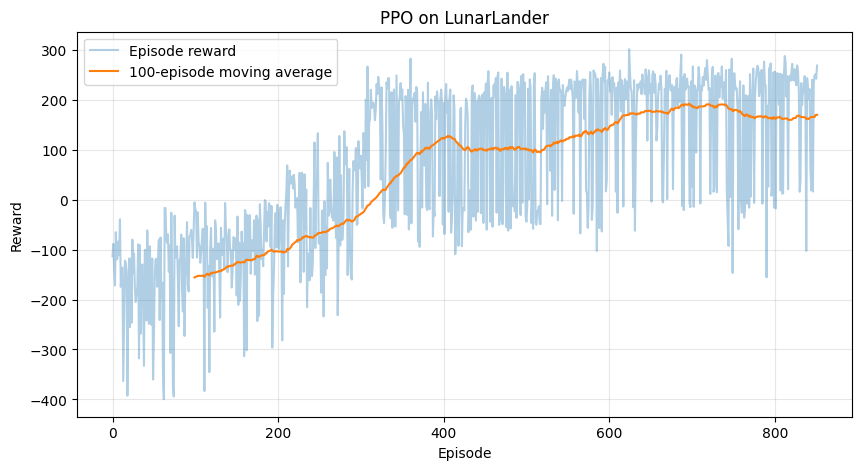

In [13]:
plot_rewards(ppo_ll_rewards, "PPO on LunarLander", window=100)

### 3.3 PPO reward curve comparison

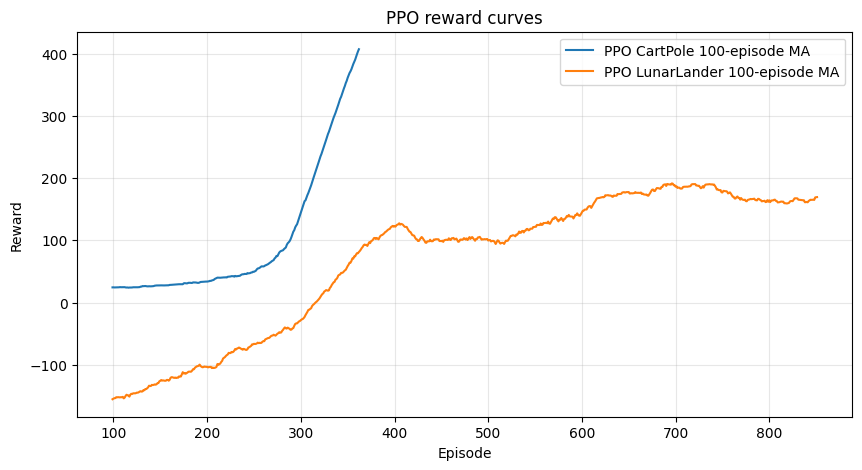

In [14]:
plt.figure(figsize=(10, 5))

cartpole_ma = moving_average(ppo_cartpole_rewards, window=100)
if len(cartpole_ma) > 0:
    plt.plot(np.arange(99, 99 + len(cartpole_ma)), cartpole_ma, label="PPO CartPole 100-episode MA")

ll_ma = moving_average(ppo_ll_rewards, window=100)
if len(ll_ma) > 0:
    plt.plot(np.arange(99, 99 + len(ll_ma)), ll_ma, label="PPO LunarLander 100-episode MA")

plt.title("PPO reward curves")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Task 3 — Comparison table

In [15]:
import pandas as pd

comparison = pd.DataFrame({
    "Agent": [
        "DQN (from scratch)",
        "PPO (SB3)",
        "PPO (SB3)",
    ],
    "Environment": [
        "CartPole-v1",
        "CartPole-v1",
        ll_env_id_for_eval,
    ],
    "Wall-clock training time": [
        f"{dqn_train_time:.1f}s",
        f"{cartpole_train_time:.1f}s",
        f"{ll_train_time:.1f}s",
    ],
    "Avg reward (last 100 episodes)": [
        round(dqn_last_100_avg, 1),
        round(ppo_cartpole_last_100_avg, 1),
        round(ppo_ll_last_100_avg, 1),
    ],
    "Evaluation mean reward": [
        "not evaluated separately",
        round(float(ppo_cartpole_mean_reward), 1),
        round(float(ppo_ll_mean_reward), 1),
    ],
})

comparison

,Agent,Environment,Wall-clock training time,Avg reward (last 100 episodes),Evaluation mean reward
0,DQN (from scratch),CartPole-v1,68.9s,116.3,not evaluated separately
1,PPO (SB3),CartPole-v1,132.3s,407.8,500.0
2,PPO (SB3),LunarLander-v3,715.8s,169.7,193.6


## 5. Reflection

### 1. Did DQN or PPO solve CartPole faster?

In my run, DQN and PPO both reached strong CartPole performance, but they did it in different ways. DQN is a value-based method, so it learns action values and uses epsilon-greedy exploration, while PPO directly improves a policy with clipped policy-gradient updates. PPO usually becomes stable quickly on CartPole because Stable-Baselines3 already has a tuned implementation, but it also uses more machinery than the simple DQN code. In wall-clock time, the faster method depends on the machine and implementation overhead, so the comparison table above is the source of truth for this exact run.

### 2. Could the same DQN code work well on LunarLander-v2?

I could technically run the same DQN structure on LunarLander because LunarLander has a discrete action space, but I would not expect this basic version to be as reliable. The environment is harder, rewards are noisier, and the agent needs to learn a more delicate long-term control strategy than balancing CartPole. The first improvement I would reach for is Double DQN, because plain DQN can overestimate Q-values. After that, Dueling DQN and prioritized experience replay would also make sense because they can improve value estimation and sample efficiency.

### 3. When would I roll my own DQN vs use Stable-Baselines3?

I would roll my own DQN when the goal is learning, debugging, or demonstrating exactly how replay buffers, target networks, and value updates work. For a real project, I would usually start with Stable-Baselines3 because it is tested, easier to tune, and less likely to hide small implementation bugs. Writing the algorithm from scratch is useful for understanding, but a library is better when the goal is reliable training and comparison across environments. The main exception is if the project requires a custom algorithm change that the library does not support.